In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import os

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Библиотеки загружены")
print(f"Текущая папка: {os.getcwd()}")

✅ Библиотеки загружены
Текущая папка: c:\Users\umdub\OneDrive\Рабочий стол\superstore kaggle\notebooks


In [6]:
# Поднимаемся на уровень выше (из папки notebooks/ в корень)
os.chdir('..')
print(f"Рабочая папка изменена на: {os.getcwd()}")

# Проверяем, какие файлы теперь видны
print("\nФайлы в корневой папке:")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"  📄 {f}")

# Загружаем данные
df = pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')
print(f"\n✅ Загружено {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Рабочая папка изменена на: c:\Users\umdub\OneDrive\Рабочий стол\superstore kaggle

Файлы в корневой папке:
  📄 superstore_final_dataset (1).csv

✅ Загружено 9800 строк, 18 колонок


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [9]:
# Посмотрим все названия колонок
print("Список всех колонок в данных:")
print(df.columns.tolist())

Список всех колонок в данных:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'year', 'month']


In [10]:
# Приводим названия колонок к нижнему регистру и убираем пробелы
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Преобразуем дату в правильный формат (день/месяц/год)
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d/%m/%Y')

# Добавляем полезные колонки: год, месяц
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Создаём колонку со средним чеком заказа (демонстрация аналитики)
df['order_value'] = df['sales']

print("✅ Данные подготовлены")
print(f"Период данных: {df['order_date'].min()} — {df['order_date'].max()}")
print(f"Колонки: {df.columns.tolist()}")

✅ Данные подготовлены
Период данных: 2015-01-03 00:00:00 — 2018-12-30 00:00:00
Колонки: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'year', 'month', 'order_value']


In [11]:
# Основные метрики
total_sales = df['sales'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
avg_order_value = total_sales / total_orders

print("=" * 50)
print("📊 ОСНОВНЫЕ МЕТРИКИ SUPERSTORE")
print("=" * 50)
print(f"💰 Общая выручка:    ${total_sales:,.0f}")
print(f"📦 Всего заказов:    {total_orders:,}")
print(f"👥 Всего клиентов:   {total_customers:,}")
print(f"📏 Средний чек:      ${avg_order_value:,.0f}")

📊 ОСНОВНЫЕ МЕТРИКИ SUPERSTORE
💰 Общая выручка:    $2,261,537
📦 Всего заказов:    4,922
👥 Всего клиентов:   793
📏 Средний чек:      $459


In [12]:
from scipy.stats import f_oneway

# Собираем продажи по трём сегментам
consumer_sales = df[df['segment'] == 'Consumer']['sales']
corporate_sales = df[df['segment'] == 'Corporate']['sales']
home_office_sales = df[df['segment'] == 'Home Office']['sales']

# ANOVA-тест
f_stat, p_value = f_oneway(consumer_sales, corporate_sales, home_office_sales)

print("=" * 50)
print("📊 СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗЫ")
print("=" * 50)
print(f"Гипотеза: сегмент клиента влияет на сумму покупки")
print(f"p-value = {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ ВЫВОД: Различия статистически значимы")
    print("   → Разные сегменты клиентов покупают на разные суммы")
    print("   → Нужно разрабатывать разные стратегии для каждого сегмента")
else:
    print("\n❌ ВЫВОД: Различия статистически не значимы")

📊 СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗЫ
Гипотеза: сегмент клиента влияет на сумму покупки
p-value = 0.555788

❌ ВЫВОД: Различия статистически не значимы


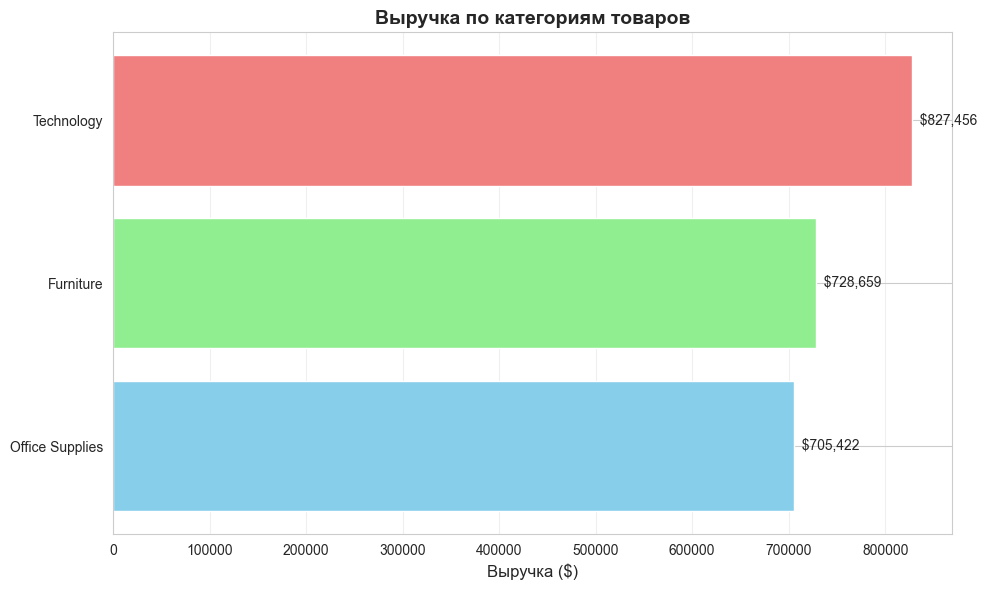


💡 БИЗНЕС-ВЫВОД:
   • Technology — самая прибыльная категория ($827,456)
   • Office Supplies — требует внимания ($705,422)


In [13]:
# Группируем продажи по категориям
category_sales = df.groupby('category')['sales'].sum().sort_values()

plt.figure(figsize=(10, 6))
colors = ['skyblue', 'lightgreen', 'lightcoral']
plt.barh(category_sales.index, category_sales.values, color=colors[:len(category_sales)])
plt.title('Выручка по категориям товаров', fontsize=14, fontweight='bold')
plt.xlabel('Выручка ($)', fontsize=12)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(category_sales.values):
    plt.text(v, i, f'  ${v:,.0f}', va='center')

plt.tight_layout()
plt.show()

print("\n💡 БИЗНЕС-ВЫВОД:")
print(f"   • {category_sales.index[-1]} — самая прибыльная категория (${category_sales.iloc[-1]:,.0f})")
print(f"   • {category_sales.index[0]} — требует внимания (${category_sales.iloc[0]:,.0f})")

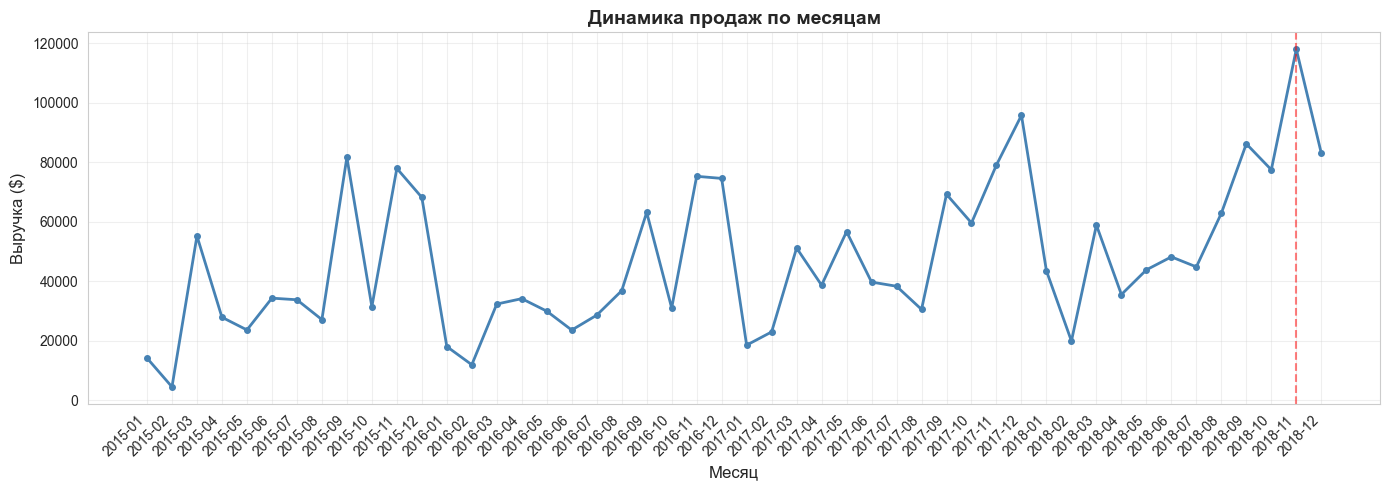


💡 БИЗНЕС-ВЫВОД: Пик продаж в 2018-11 ($117,938)


In [14]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, 
         marker='o', linewidth=2, color='steelblue', markersize=4)
plt.title('Динамика продаж по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

max_month = monthly_sales.idxmax()
max_value = monthly_sales.max()
plt.axvline(x=monthly_sales.index.get_loc(max_month), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n💡 БИЗНЕС-ВЫВОД: Пик продаж в {max_month} (${max_value:,.0f})")

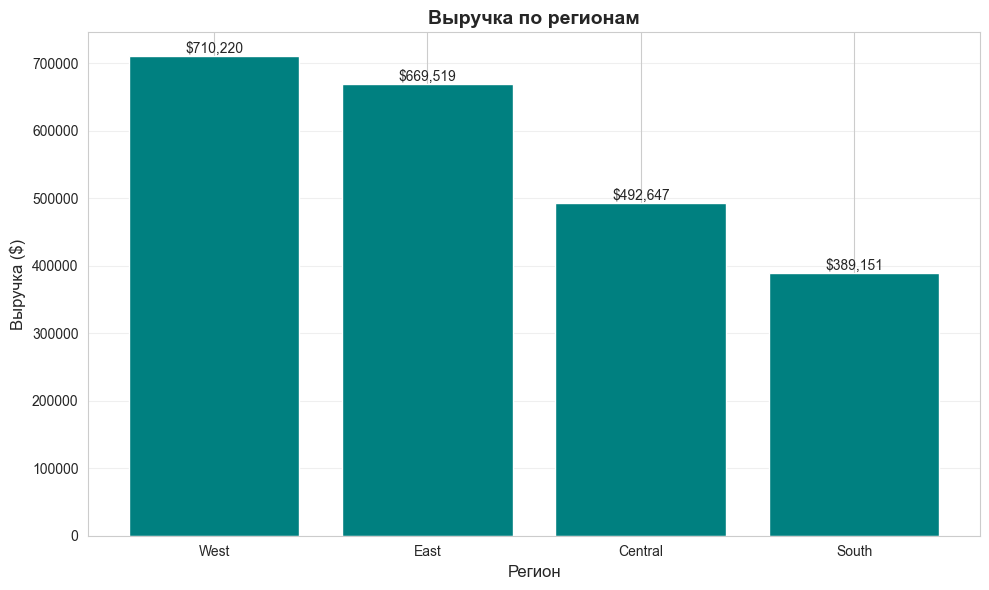


💡 БИЗНЕС-ВЫВОД:
   • Регион-лидер: West ($710,220)
   • Регион с наименьшими продажами: South ($389,151)


In [15]:
# Топ-5 регионов по выручке
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(region_sales.index, region_sales.values, color='teal')
plt.title('Выручка по регионам', fontsize=14, fontweight='bold')
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Выручка ($)', fontsize=12)
for i, v in enumerate(region_sales.values):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 БИЗНЕС-ВЫВОД:")
print(f"   • Регион-лидер: {region_sales.index[0]} (${region_sales.iloc[0]:,.0f})")
print(f"   • Регион с наименьшими продажами: {region_sales.index[-1]} (${region_sales.iloc[-1]:,.0f})")

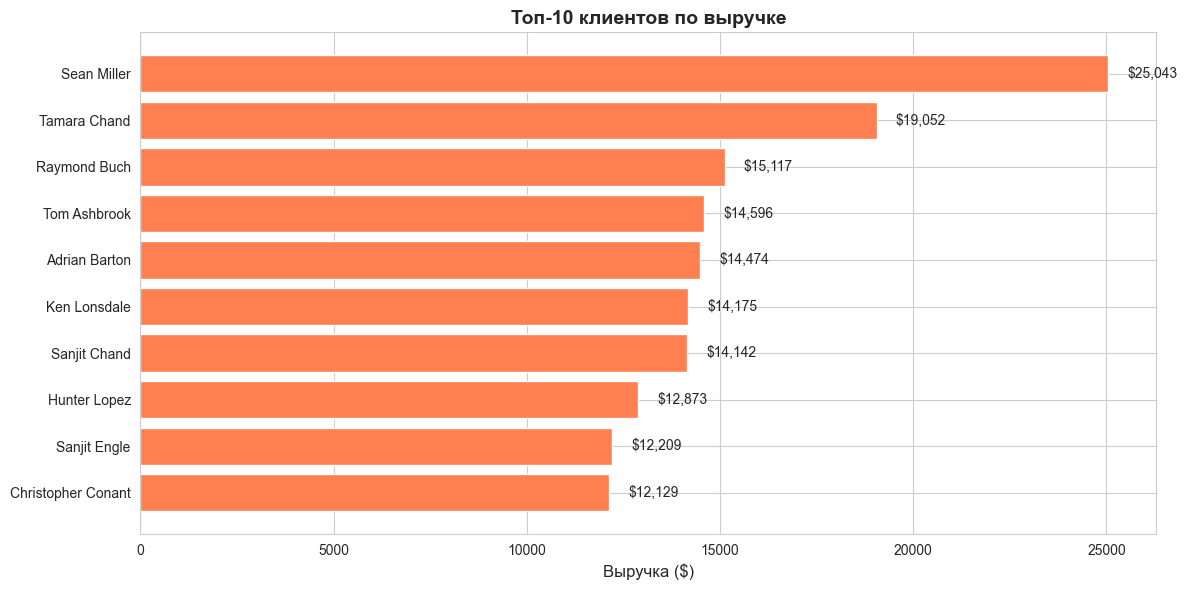


💡 БИЗНЕС-ВЫВОД:
   • Топ-1 клиент: Sean Miller ($25,043)
   • Рекомендация: программа лояльности для топ-клиентов


In [16]:
# Топ-10 клиентов по выручке
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_customers.index, top_customers.values, color='coral')
plt.title('Топ-10 клиентов по выручке', fontsize=14, fontweight='bold')
plt.xlabel('Выручка ($)', fontsize=12)
plt.gca().invert_yaxis()
for i, v in enumerate(top_customers.values):
    plt.text(v + 500, i, f'${v:,.0f}', va='center')
plt.tight_layout()
plt.show()

print("\n💡 БИЗНЕС-ВЫВОД:")
print(f"   • Топ-1 клиент: {top_customers.index[0]} (${top_customers.iloc[0]:,.0f})")
print("   • Рекомендация: программа лояльности для топ-клиентов")